Trabalho Final Análise Exploratória de Dados - André Abritta Nogueira - 2026013740

Bibliotecas Utilizadas:

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Código para ler o dataset:

In [17]:
path = "tmdb_5000_movies.csv"
df = pd.read_csv(path)

Etapa 1: Entendimento dos Dados 

1. Contexto da Base

Esta base de dados é composta por metadados de aproximadamente 5.000 filmes registrados no The Movie Database (TMDB), uma plataforma popular e colaborativa que reúne dados detalhados sobre o cinema mundial. O conjunto de dados abrange várias décadas de produções cinematográficas, integrando informações financeiras (orçamentos e receitas), dados textuais de marketing (sinopses, títulos e frases de efeito), informações operacionais de produção (países, estúdios e idiomas) e métricas de recepção do público (votos, médias e popularidade).

2. Objetivo da Coleta dos Dados

O principal objetivo da consolidação desses dados é permitir o estudo analítico e comercial da indústria do cinema. De forma prática, a coleta serve para:

Análise de Desempenho Financeiro: Avaliar o retorno sobre o investimento (relação entre orçamento e receita de bilheteria).

Sistemas de Recomendação: Cruzar gêneros, palavras-chave e notas para sugerir produções semelhantes aos usuários.

Modelagem Preditiva: Entender quais fatores (como elenco, data de lançamento ou estúdio de produção) têm maior impacto na popularidade ou no sucesso comercial de um filme.

3. Descrição das Variáveis

Abaixo estão detalhadas todas as variáveis contidas no cabeçalho do arquivo CSV:

budget: O orçamento total estimado para a produção do filme (em dólares americanos).

genres: Uma lista em formato JSON contendo os gêneros associados ao filme (ex: Ação, Comédia, Drama).

homepage: O endereço eletrônico (URL) oficial da página de divulgação do filme.

id: Um número de identificação exclusivo associado ao filme no sistema do TMDB.

keywords: Uma lista em formato JSON contendo palavras-chave e termos que resumem os temas do filme.

original_language: O idioma no qual o filme foi originalmente gravado (código ISO de duas letras, ex: en, es, pt).

original_title: O título do filme em seu idioma e país de origem.

overview: Uma sinopse textual curta ou resumo do enredo do filme.

popularity: Um índice numérico calculado pelo algoritmo do TMDB que mede o engajamento e a popularidade atual do filme na plataforma.

production_companies: Uma lista em formato JSON com os nomes e IDs dos estúdios envolvidos na produção.

production_countries: Uma lista em formato JSON especificando os países onde o filme foi produzido.

release_date: A data oficial de lançamento comercial do filme (no formato AAAA-MM-DD).

revenue: A receita total arrecadada mundialmente nas bilheterias (em dólares americanos).

runtime: O tempo total de duração do filme medido em minutos.

spoken_languages: Uma lista em formato JSON detalhando todos os idiomas falados ao longo do filme.

status: O estado operacional de lançamento do filme (valores comuns incluem Released [Lançado] ou Rumored [Rumor]).

tagline: A frase de efeito ou bordão promocional utilizado no material de marketing do filme.

title: O título comercial do filme ou sua tradução internacional mais utilizada em inglês.

vote_average: A nota média recebida pelo filme, calculada a partir das avaliações dos usuários (escala de 0 a 10).

vote_count: O número total de usuários que computaram um voto para o filme na plataforma.

4. Classificação das Variáveis

A) Quantitativas Contínuas: popularity; vote_average

B) Quantitativas Discretas: vote_count; runtime; budget; revenue

C) Qualitativas Nominais: id; title; original_title; genres; homepage; keywords; original_language; spoken_languages; overview; tagline; production_companies; production_countries; status

D) Qualitativas Ordinais: release_date

Etapa 2: Auditoria de Dados

In [18]:
print("--- 1. VALORES AUSENTES (Missing Values) ---")
ausentes = df.isnull().sum()
print(ausentes[ausentes > 0])

print("\n--- 2. REGISTROS DUPLICADOS ---")
print(f"Total de linhas estritamente duplicadas: {df.duplicated().sum()}")

print("\n--- 3. INCONSISTÊNCIAS (Valores '0' ilógicos) ---")
# Em filmes, não faz sentido orçamento, receita ou tempo de duração serem iguais a zero.
print(f"Filmes com Orçamento (budget) = 0: {(df['budget'] == 0).sum()}")
print(f"Filmes com Receita (revenue) = 0: {(df['revenue'] == 0).sum()}")
print(f"Filmes com Duração (runtime) = 0: {(df['runtime'] == 0).sum()}")

print("\n--- 4. VALORES EXTREMOS (OUTLIERS) ---")
def contar_outliers(coluna):
    Q1 = coluna.quantile(0.25)
    Q3 = coluna.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = coluna[(coluna < limite_inferior) | (coluna > limite_superior)]
    return len(outliers)

colunas_numericas = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']
for col in colunas_numericas:
    qtd = contar_outliers(df[col])
    print(f"Coluna '{col}': {qtd} potenciais outliers")

--- 1. VALORES AUSENTES (Missing Values) ---
homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

--- 2. REGISTROS DUPLICADOS ---
Total de linhas estritamente duplicadas: 0

--- 3. INCONSISTÊNCIAS (Valores '0' ilógicos) ---
Filmes com Orçamento (budget) = 0: 1037
Filmes com Receita (revenue) = 0: 1427
Filmes com Duração (runtime) = 0: 35

--- 4. VALORES EXTREMOS (OUTLIERS) ---
Coluna 'budget': 321 potenciais outliers
Coluna 'revenue': 472 potenciais outliers
Coluna 'runtime': 182 potenciais outliers
Coluna 'popularity': 275 potenciais outliers
Coluna 'vote_average': 156 potenciais outliers
Coluna 'vote_count': 504 potenciais outliers


Limpeza dos Dados: Substituição de zeros por NaN

In [19]:
df['budget']  = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)
df['runtime'] = df['runtime'].replace(0, np.nan)

Etapa 3: Analise Univariada

Código para calculo de:
- Mediana;
- Moda (quando aplicável);
- Variância;
- Desvio-padrão;
- Coeficiente de variação;
- Assimetria;
- Quartis.

E depois criação de csv para exportação e criação de tabela

In [20]:
colunas_numericas = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']
colunas_em_milhoes = {'budget', 'revenue'}

resultados = {}

for coluna in colunas_numericas:
    dados = df[coluna].dropna()

    fator = 1_000_000 if coluna in colunas_em_milhoes else 1
    dados_calc = dados / fator

    media = dados_calc.mean()
    mediana = dados_calc.median()
    moda = dados_calc.mode().iloc[0] if not dados_calc.mode().empty else np.nan
    variancia = dados_calc.var()
    desvio_padrao = dados_calc.std()
    coef_variacao = (desvio_padrao / media) * 100 if media != 0 else np.nan
    assimetria = dados_calc.skew()
    q1 = dados_calc.quantile(0.25)
    q2 = dados_calc.quantile(0.50)
    q3 = dados_calc.quantile(0.75)

    resultados[coluna] = {
        'Média': round(media, 2),
        'Mediana': round(mediana, 2),
        'Moda': round(moda, 2),
        'Variância': round(variancia, 2),
        'Desvio Padrão': round(desvio_padrao, 2),
        'Coef. Variação (%)': round(coef_variacao, 2),
        'Assimetria': round(assimetria, 2),
        'Q1 (25%)': round(q1, 2),
        'Q2 (50%)': round(q2, 2),
        'Q3 (75%)': round(q3, 2)
    }

df_resultados = pd.DataFrame(resultados).T
df_resultados.index.name = 'Variável'

display(df_resultados)

df_resultados.to_csv('estatisticas_univariadas_tmdb.csv', encoding='utf-8-sig')

,Média,Mediana,Moda,Variância,Desvio Padrão,Coef. Variação (%),Assimetria,Q1 (25%),Q2 (50%),Q3 (75%)
Variável,,,,,,,,,,
budget,37.04,23.00,20.0,1818.73,42.65,115.13,2.22,8.00,23.00,50.00
revenue,117.03,51.75,7.0,33666.04,183.48,156.78,3.89,15.35,51.75,140.17
runtime,107.66,104.00,90.0,430.54,20.75,19.27,1.82,94.00,104.00,118.00
popularity,21.49,12.92,8.9,1012.30,31.82,148.04,9.72,4.67,12.92,28.31
vote_average,6.09,6.20,6.0,1.43,1.19,19.61,-1.96,5.60,6.20,6.80
vote_count,690.22,235.00,0.0,1524202.32,1234.59,178.87,3.82,54.00,235.00,737.00


Histogramas e Boxplots:

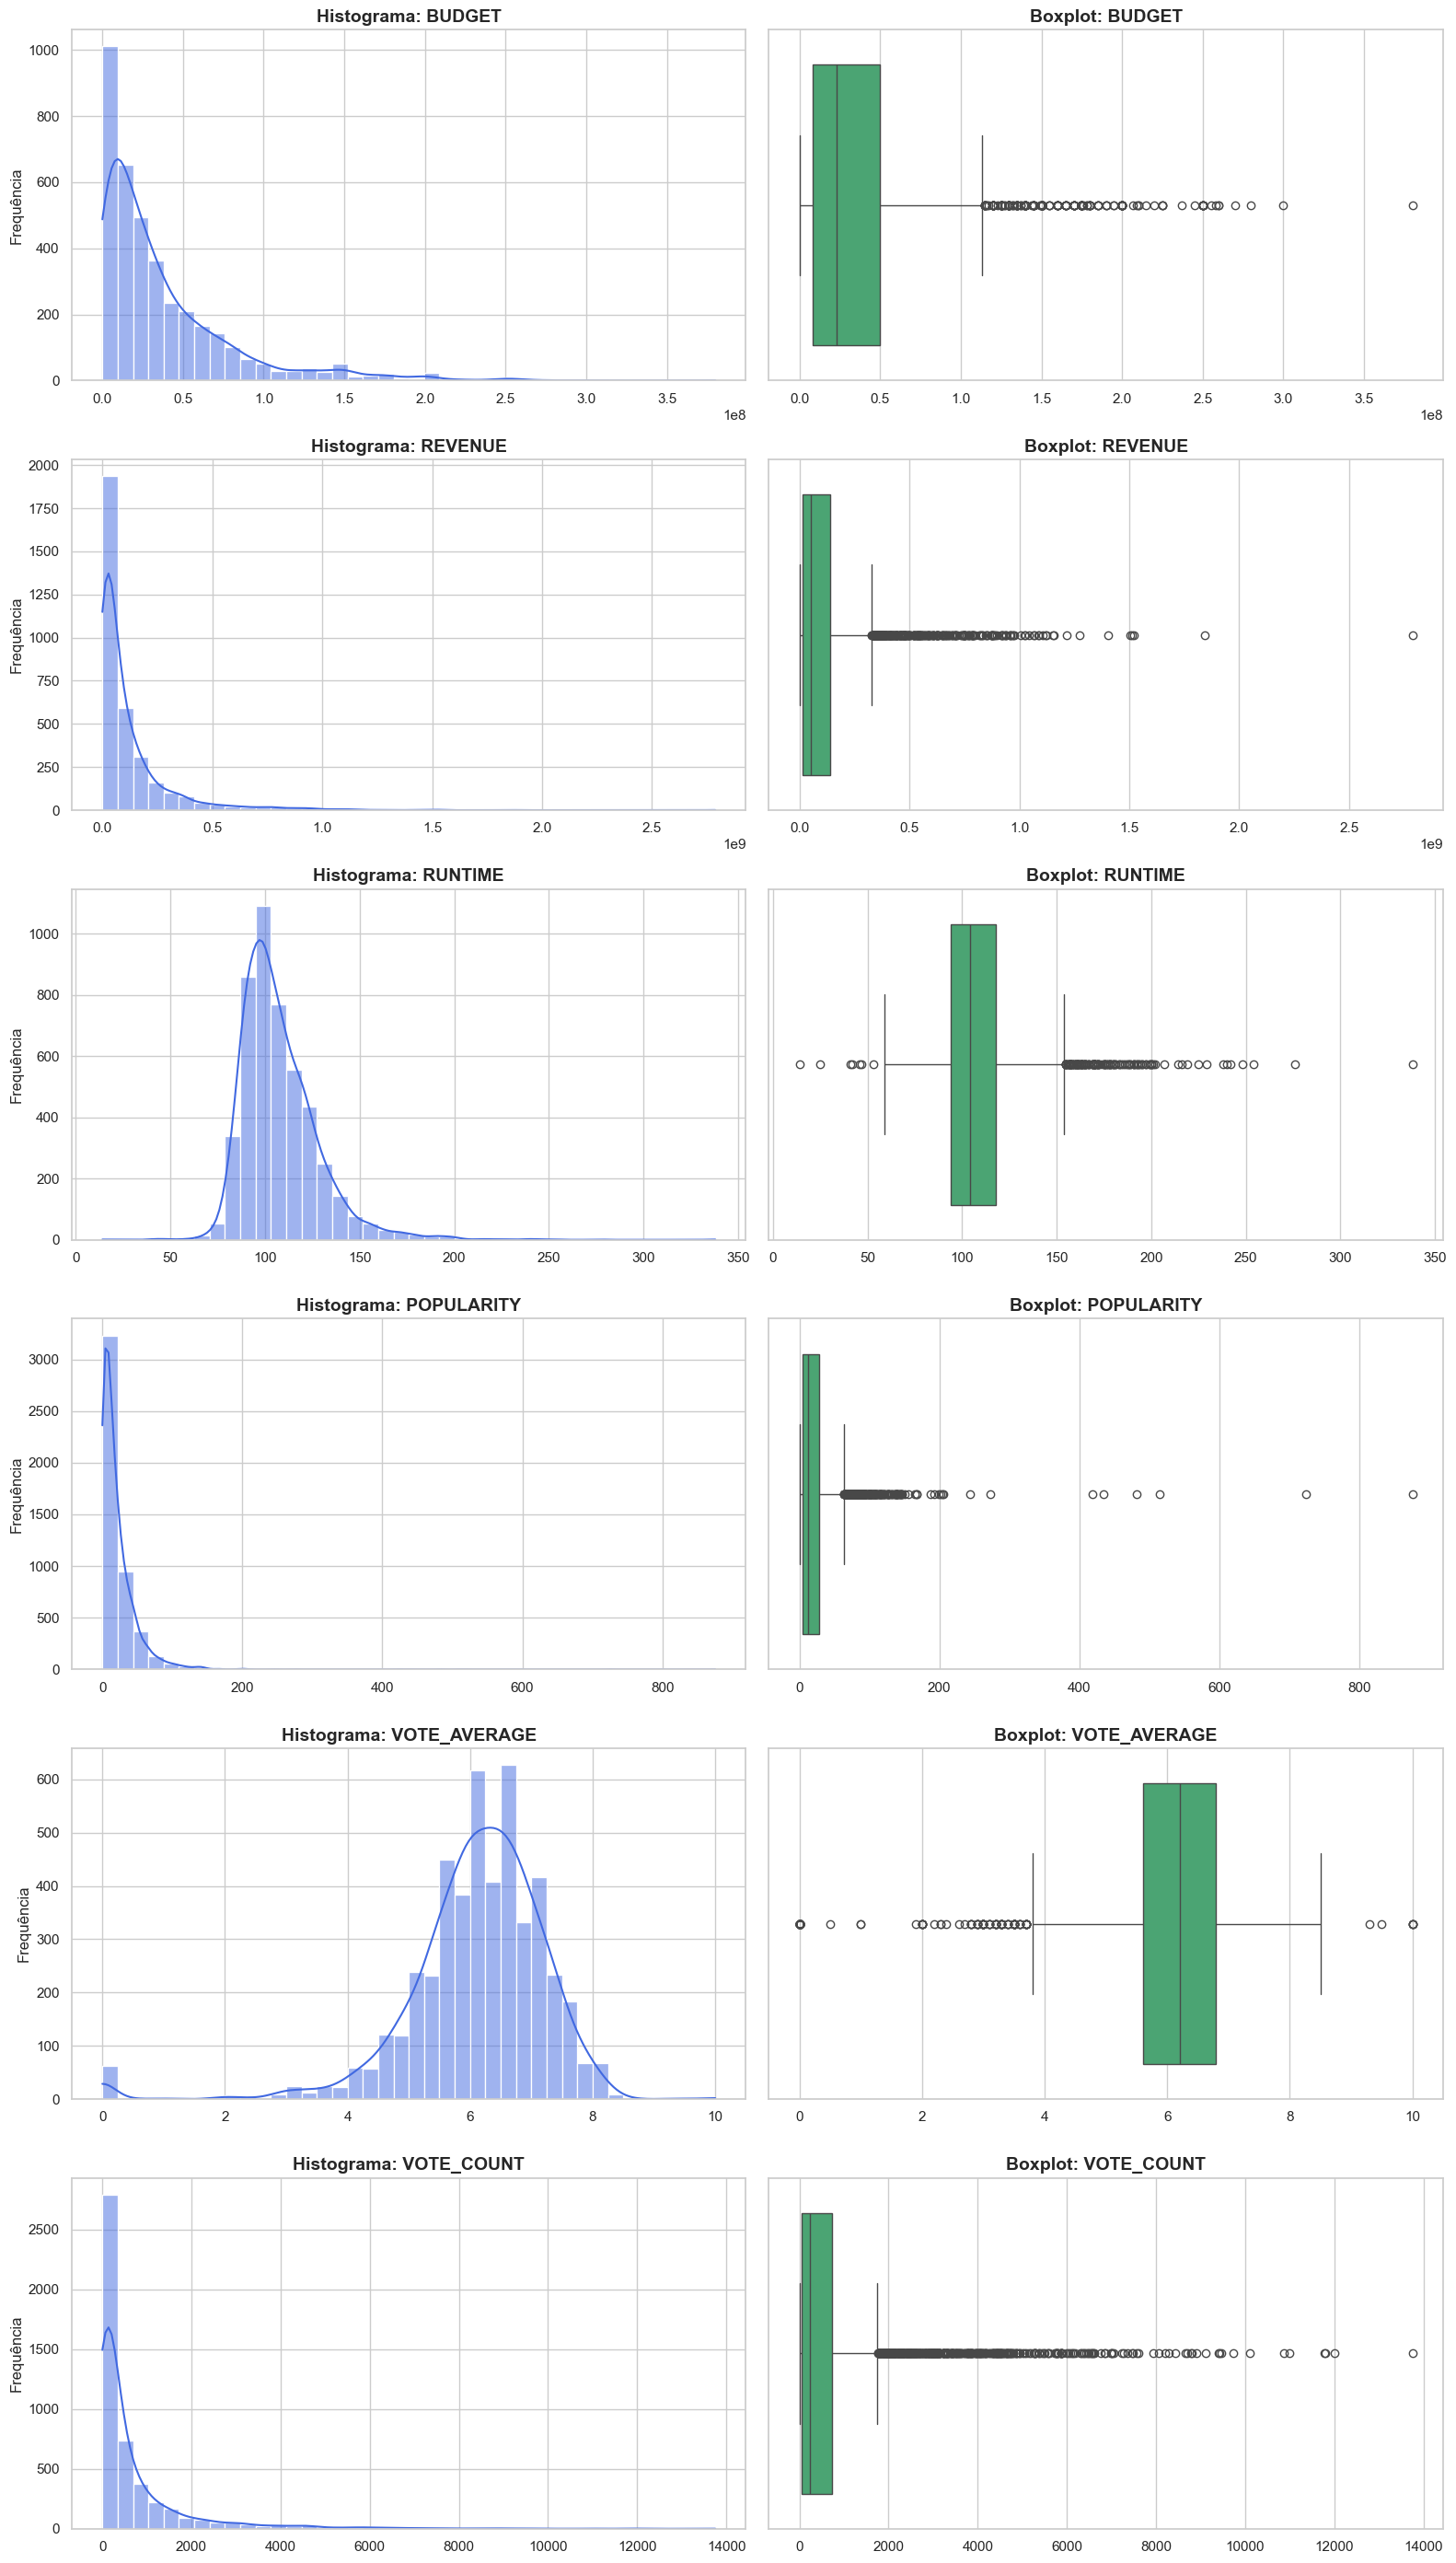

In [21]:
# Configuração visual
sns.set_theme(style="whitegrid")

# 3. Lista das variáveis numéricas
variaveis = [
    'budget', 
    'revenue', 
    'runtime', 
    'popularity', 
    'vote_average', 
    'vote_count'
]

# 4. Criação da figura principal (Painel de 6 linhas x 2 colunas)
# Ajustamos o tamanho (figsize) para que os gráficos não fiquem espremidos
fig, axes = plt.subplots(nrows=len(variaveis), ncols=2, figsize=(16, 28))

# 5. Loop para plotar cada variável automaticamente
for i, col in enumerate(variaveis):
    dados = df[col].dropna() # Remove os nulos apenas para a plotagem
    
    # Plot do Histograma (Coluna Esquerda)
    sns.histplot(dados, bins=40, kde=True, ax=axes[i, 0], color="royalblue")
    axes[i, 0].set_title(f'Histograma: {col.upper()}', fontsize=14, fontweight='bold')
    axes[i, 0].set_ylabel('Frequência')
    axes[i, 0].set_xlabel('')
    
    # Plot do Boxplot (Coluna Direita)
    sns.boxplot(x=dados, ax=axes[i, 1], color="mediumseagreen")
    axes[i, 1].set_title(f'Boxplot: {col.upper()}', fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel('')

# 6. Ajusta o espaçamento para não sobrepor os títulos
plt.tight_layout()

# 7. Exibe o painel completo
plt.show()

Conclusão: 
- As médias de budget e revenue são infladas devido aos grandes sucessos do cinema (outliers)
- Filmes populares e que geram dinheiro são a excessão. A maioria dos filmes está na parte direita do gráfico, indicando assimetria positiva. 
- A nota média dos filmes é 6.09 e não é muito inflada por outliers, ja que a maior parte dos dados está entre 5 e 7, demonstrando que a maioria dos filmes é mediano para bom na visão do publico/critica
- A maior parte dos filmes tem entre 90 a 120 minutos de duração (1h30min - 2h), indicando que filmes muito curtos ou muito longos são a excessão


Etapa 4: Análise Bivariada

Código para geração de matriz de correlação

Registros utilizados na análise bivariada: 3229


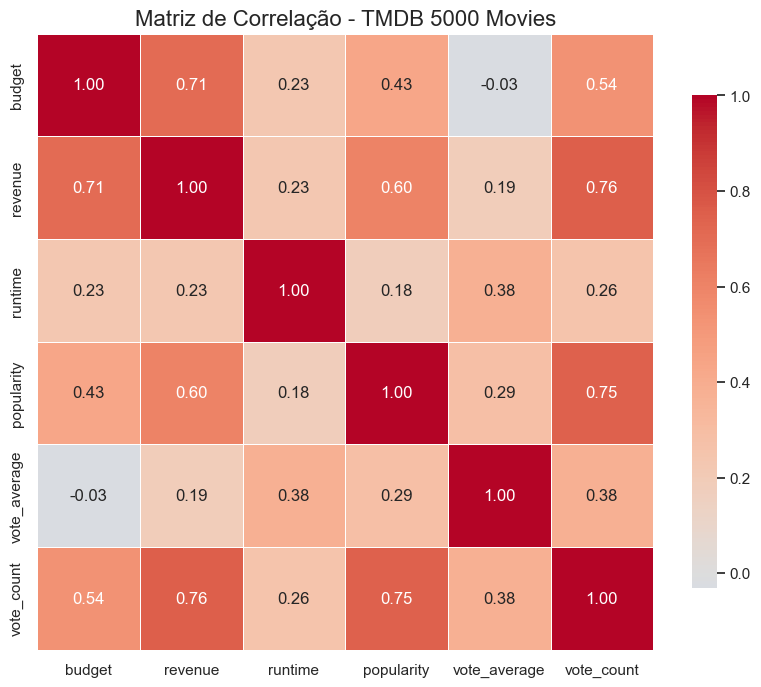

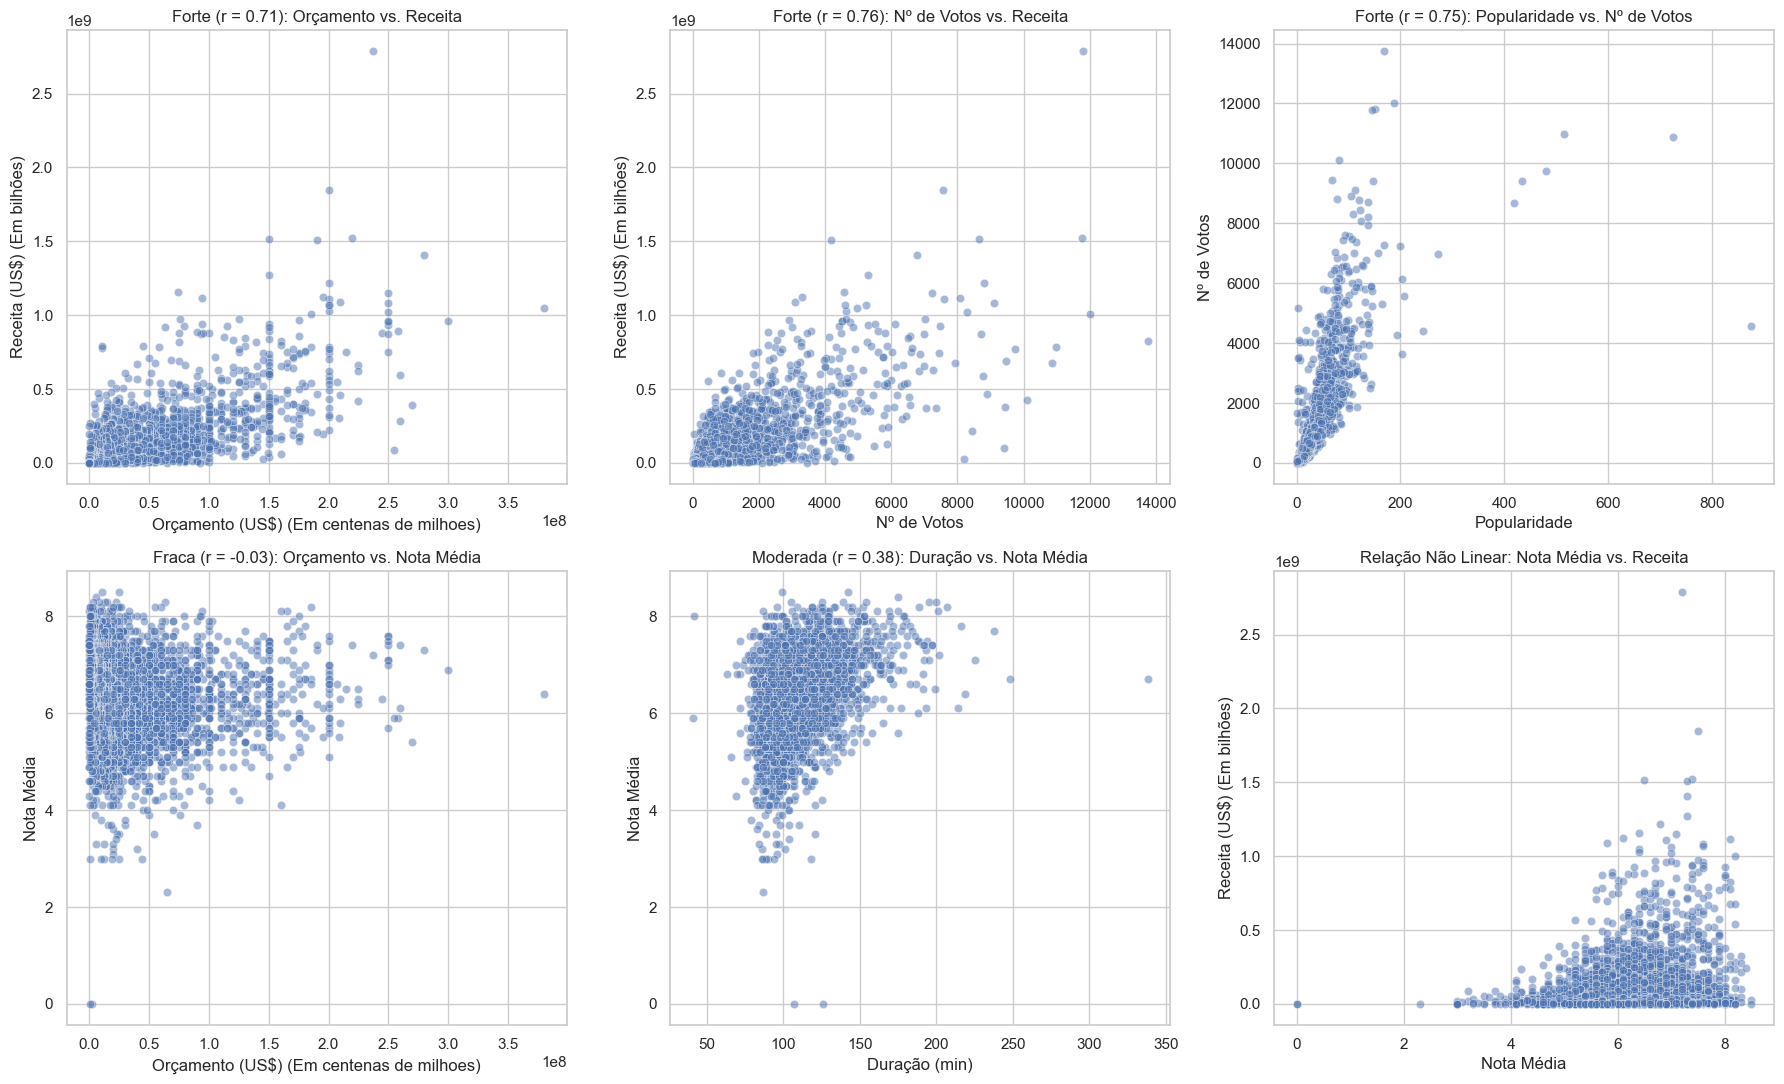


DISCUSSÃO – ANÁLISE BIVARIADA

📌 CORRELAÇÕES FORTES (|r| ≥ 0.60):
  Receita (US$) (Em bilhões) × Nº de Votos: r = 0.76
  Popularidade × Nº de Votos: r = 0.75
  Orçamento (US$) (Em centenas de milhoes) × Receita (US$) (Em bilhões): r = 0.71
  Receita (US$) (Em bilhões) × Popularidade: r = 0.60

📌 CORRELAÇÕES MODERADAS (0.30 ≤ |r| < 0.60):
  Orçamento (US$) (Em centenas de milhoes) × Nº de Votos: r = 0.54
  Orçamento (US$) (Em centenas de milhoes) × Popularidade: r = 0.43
  Duração (min) × Nota Média: r = 0.38
  Nota Média × Nº de Votos: r = 0.38

📌 CORRELAÇÕES FRACAS (|r| < 0.30):
  Popularidade × Nota Média: r = 0.29
  Duração (min) × Nº de Votos: r = 0.26
  Receita (US$) (Em bilhões) × Duração (min): r = 0.23
  Orçamento (US$) (Em centenas de milhoes) × Duração (min): r = 0.23
  Receita (US$) (Em bilhões) × Nota Média: r = 0.19
  Duração (min) × Popularidade: r = 0.18
  Orçamento (US$) (Em centenas de milhoes) × Nota Média: r = -0.03

📌 RELAÇÃO NÃO LINEAR IDENTIFICADA:
  Nota Média ×

In [22]:
colunas_numericas = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']
df_limpo = df[colunas_numericas].dropna()

print(f"Registros utilizados na análise bivariada: {len(df_limpo)}")

rotulos = {
    'budget':       'Orçamento (US$) (Em centenas de milhoes)',
    'revenue':      'Receita (US$) (Em bilhões)',
    'runtime':      'Duração (min)',
    'popularity':   'Popularidade',
    'vote_average': 'Nota Média',
    'vote_count':   'Nº de Votos'
}


# Matriz de Correlação
plt.figure(figsize=(10, 8))
matriz_corr = df_limpo.corr()
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação - TMDB 5000 Movies", fontsize=16)
plt.show()


# Gráficos de Dispersão – 6 pares selecionados
pares = [
    ("budget",       "revenue",      "Forte (r = 0.71): Orçamento vs. Receita"),
    ("vote_count",   "revenue",      "Forte (r = 0.76): Nº de Votos vs. Receita"),
    ("popularity",   "vote_count",   "Forte (r = 0.75): Popularidade vs. Nº de Votos"),
    ("budget",       "vote_average", "Fraca (r = -0.03): Orçamento vs. Nota Média"),
    ("runtime",      "vote_average", "Moderada (r = 0.38): Duração vs. Nota Média"),
    ("vote_average", "revenue",      "Relação Não Linear: Nota Média vs. Receita"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
sns.set_theme(style="whitegrid")
axes_flat = axes.flatten()

for ax, (x, y, titulo) in zip(axes_flat, pares):
    sns.scatterplot(data=df_limpo, x=x, y=y, alpha=0.5, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel(rotulos[x])
    ax.set_ylabel(rotulos[y])

plt.tight_layout()
plt.show()


# Resumo das correlações
colunas = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']
pares_corr = []
for i, c1 in enumerate(colunas):
    for c2 in colunas[i+1:]:
        r = matriz_corr.loc[c1, c2]
        pares_corr.append((abs(r), r, c1, c2))

pares_corr.sort(reverse=True)

print("\n" + "="*60)
print("DISCUSSÃO – ANÁLISE BIVARIADA")
print("="*60)

print("\n📌 CORRELAÇÕES FORTES (|r| ≥ 0.60):")
for absr, r, c1, c2 in pares_corr:
    if absr >= 0.60:
        print(f"  {rotulos[c1]} × {rotulos[c2]}: r = {r:.2f}")

print("\n📌 CORRELAÇÕES MODERADAS (0.30 ≤ |r| < 0.60):")
for absr, r, c1, c2 in pares_corr:
    if 0.30 <= absr < 0.60:
        print(f"  {rotulos[c1]} × {rotulos[c2]}: r = {r:.2f}")

print("\n📌 CORRELAÇÕES FRACAS (|r| < 0.30):")
for absr, r, c1, c2 in pares_corr:
    if absr < 0.30:
        print(f"  {rotulos[c1]} × {rotulos[c2]}: r = {r:.2f}")

print("\n📌 RELAÇÃO NÃO LINEAR IDENTIFICADA:")
print("  Nota Média × Receita (r = 0.19): filmes com notas extremas")
print("  (muito baixas ou muito altas) tendem a ter receitas diferentes")
print("  dos filmes medianos, sugerindo uma curva em U, não uma reta.")

print("\n" + "="*60)


Etapa 5: Analise multivariada

Existe uma forte cadeia de multicolinearidade que interliga as variáveis [Orçamento $\rightarrow$ Receita $\rightarrow$ Nº de Votos $\rightarrow$ Popularidade]. Em uma eventual modelagem preditiva, incluir todas essas variáveis simultaneamente distorceria os erros padrão e tornaria os coeficientes do modelo instáveis. Para futuros modelos, seria altamente recomendável descartar variáveis puramente de engajamento (como Nº de Votos) ou aplicar técnicas de redução de dimensionalidade.

Etapa 6: Visualização Multivariada

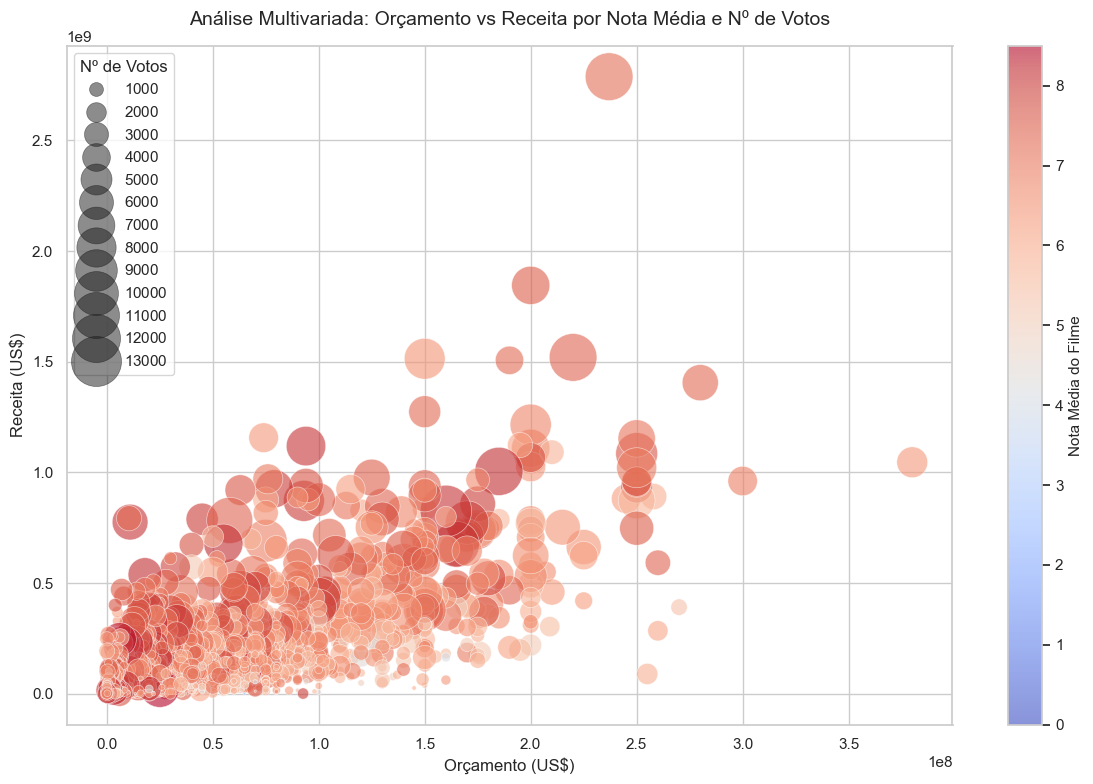

In [23]:
# Gráfico Multivariado 1: Orçamento vs Receita inflados por Nota Média e Volume de Votos
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    x=df['budget'], 
    y=df['revenue'], 
    c=df['vote_average'],          # Cor baseada na Nota Média
    cmap='coolwarm',               # Escala de cor: azul (baixa) a vermelho (alta)
    s=df['vote_count'] * 0.1,      # Tamanho do ponto baseado no Nº de Votos (ajustado por escala)
    alpha=0.6, 
    edgecolors='w', 
    linewidth=0.5
)

plt.title('Análise Multivariada: Orçamento vs Receita por Nota Média e Nº de Votos', fontsize=14, pad=15)
plt.xlabel('Orçamento (US$)', fontsize=12)
plt.ylabel('Receita (US$)', fontsize=12)

# Adicionando a barra de cores para a Nota Média
cbar = plt.colorbar(scatter)
cbar.set_label('Nota Média do Filme', fontsize=11)

# Legenda para o tamanho dos pontos (Nº de Votos)
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5, func=lambda s: s / 0.1)
plt.legend(handles, labels, loc="upper left", title="Nº de Votos")

plt.tight_layout()
plt.show()

Conclusão:
- Correlação Positiva: Maior orçamento geralmente resulta em maior receita. O investimento impulsiona a bilheteria.

- A Regra do Engajamento: Os filmes no topo (maiores receitas) sempre têm as maiores bolhas (mais votos). Sucesso financeiro exige engajamento massivo do público.

- Orçamento alto x Nota: Nem sempre filmes com maior orcamento terão as melhores notas.

- Base da Indústria: A esmagadora maioria dos filmes fica aglomerada no canto inferior esquerdo (baixo orçamento e baixa receita). Os "Blockbusters" são exceções.

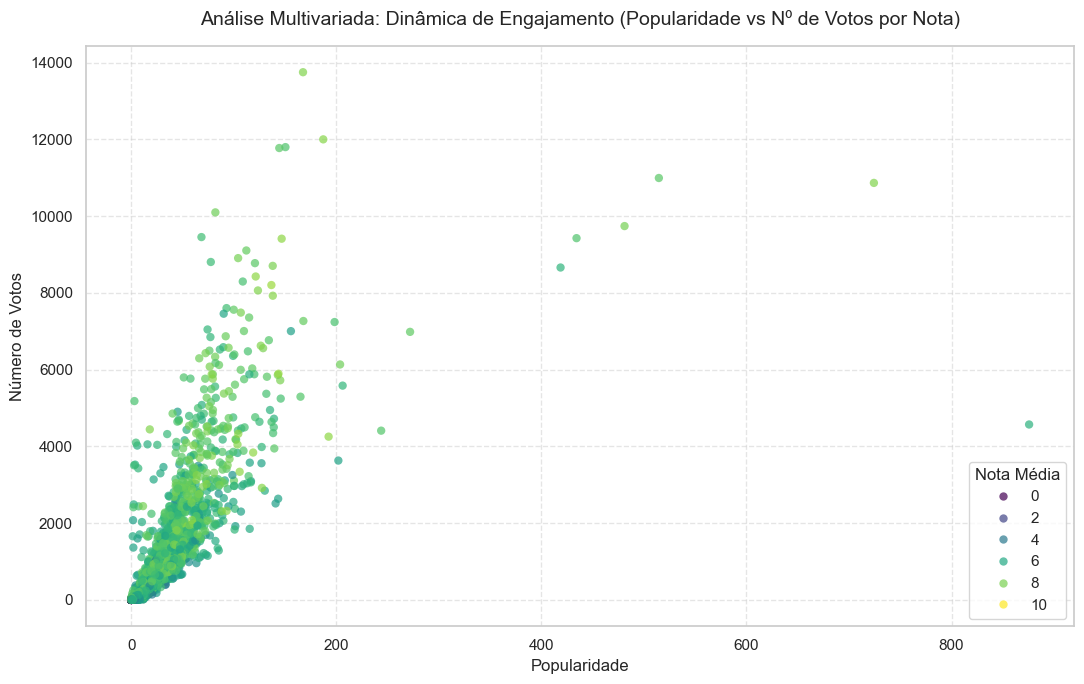

In [24]:
# Gráfico Multivariado 2: Popularidade vs Nº de Votos mapeados pela Nota Média
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df, 
    x='popularity', 
    y='vote_count', 
    hue='vote_average', 
    palette='viridis', 
    alpha=0.7,
    edgecolor='none'
)

plt.title('Análise Multivariada: Dinâmica de Engajamento (Popularidade vs Nº de Votos por Nota)', fontsize=14, pad=15)
plt.xlabel('Popularidade', fontsize=12)
plt.ylabel('Número de Votos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustando a legenda lateral
plt.legend(title='Nota Média', loc='lower right')

plt.tight_layout()
plt.show()

Conclusão:

- Relação Base: Até certo ponto, o aumento da popularidade acompanha o crescimento do número de votos.

- Clássicos Consolidados: O filme com mais votos da base (~14 mil) tem nota alta (verde-claro, ~8), mas popularidade mediana. É um sucesso histórico que não depende de "hype".

- O Efeito "Hype" (Outliers à direita): Filmes com popularidade altíssima (800+), mas poucos votos, indicam lançamentos recentes. Estão "em alta" na plataforma agora, mas não têm histórico de votos acumulado.

- Esquecimento Rápido: Filmes muito ruins (tons de roxo) não engajam. Eles ficam presos perto do zero em popularidade e em votos.

Etapa 9: Descobertas Estatísticas

FENÔMENO 1: OUTLIERS NA RECEITA (BOXPLOT)

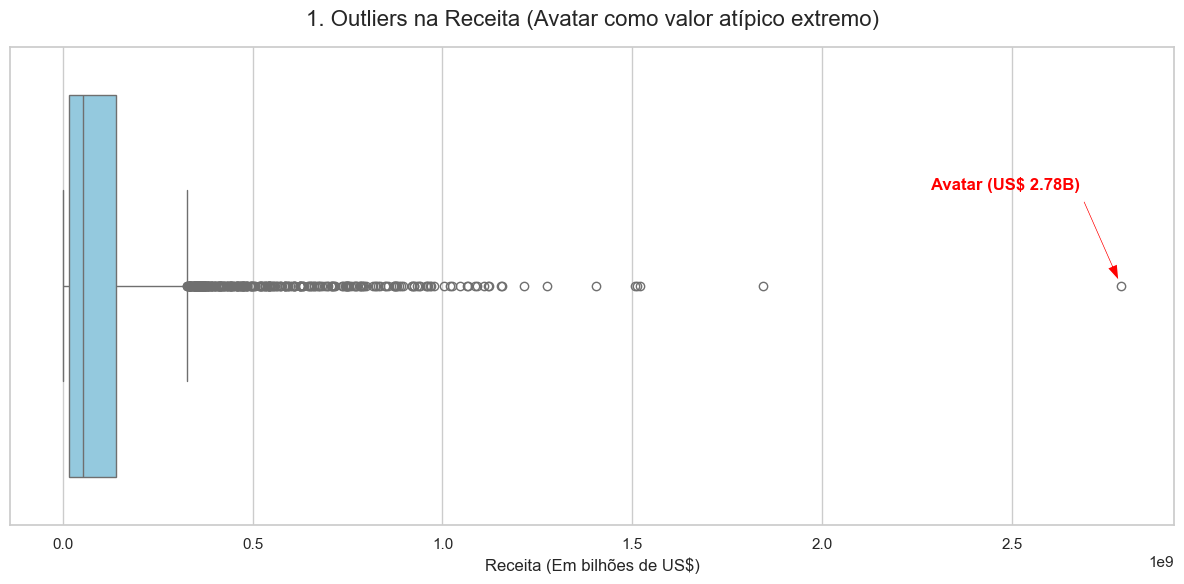

In [25]:

plt.figure(figsize=(12, 6)) # Tamanho grande para o primeiro gráfico

sns.boxplot(x=df['revenue'], color='skyblue') # Mudando para horizontal (eixo x) para ficar mais largo
plt.title('1. Outliers na Receita (Avatar como valor atípico extremo)', fontsize=16, pad=15)
plt.xlabel('Receita (Em bilhões de US$)', fontsize=12)

# Encontrando o filme com maior receita (Avatar) para anotar no gráfico
max_revenue = df['revenue'].max()
plt.annotate('Avatar (US$ 2.78B)', 
             xy=(max_revenue, 0), 
             xytext=(max_revenue - 0.5e9, -0.2),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, color='red', weight='bold')

plt.tight_layout()
plt.show()


FENÔMENO 2: ASSIMETRIA POSITIVA NA POPULARIDADE (HISTOGRAMA)

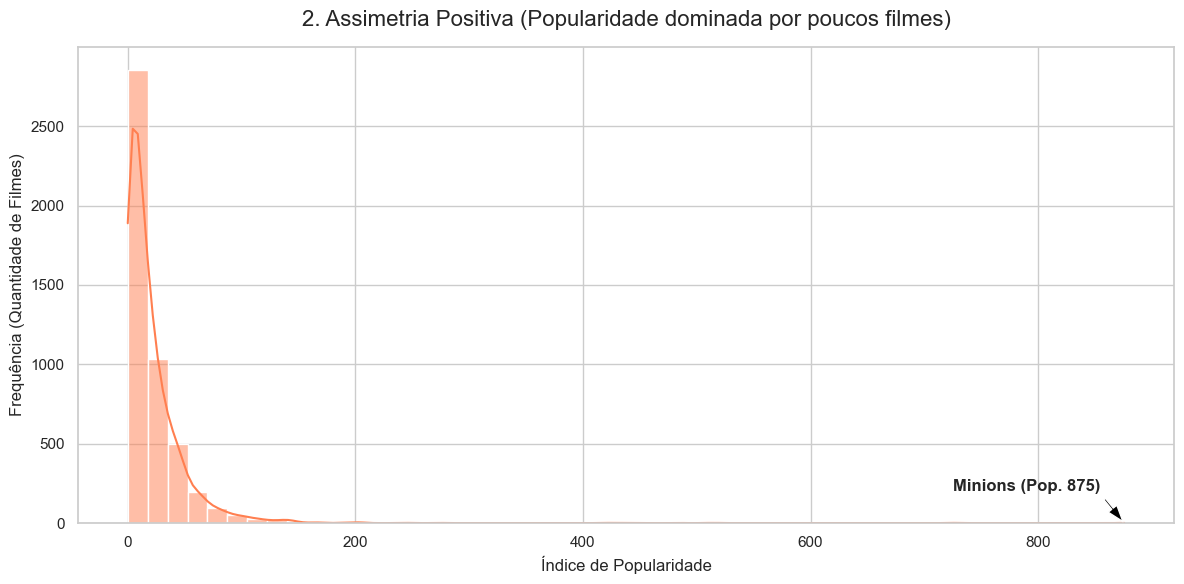

In [26]:
plt.figure(figsize=(12, 6)) # Tamanho grande para o segundo gráfico

sns.histplot(df['popularity'], bins=50, kde=True, color='coral')
plt.title('2. Assimetria Positiva (Popularidade dominada por poucos filmes)', fontsize=16, pad=15)
plt.xlabel('Índice de Popularidade', fontsize=12)
plt.ylabel('Frequência (Quantidade de Filmes)', fontsize=12)

# Encontrando o filme mais popular (Minions)
max_pop = df['popularity'].max()
plt.annotate('Minions (Pop. 875)', 
             xy=(max_pop, 0), 
             xytext=(max_pop - 150, 200),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


FENÔMENO 3: RELAÇÃO NÃO LINEAR ENTRE NOTA E RECEITA (REGPLOT)

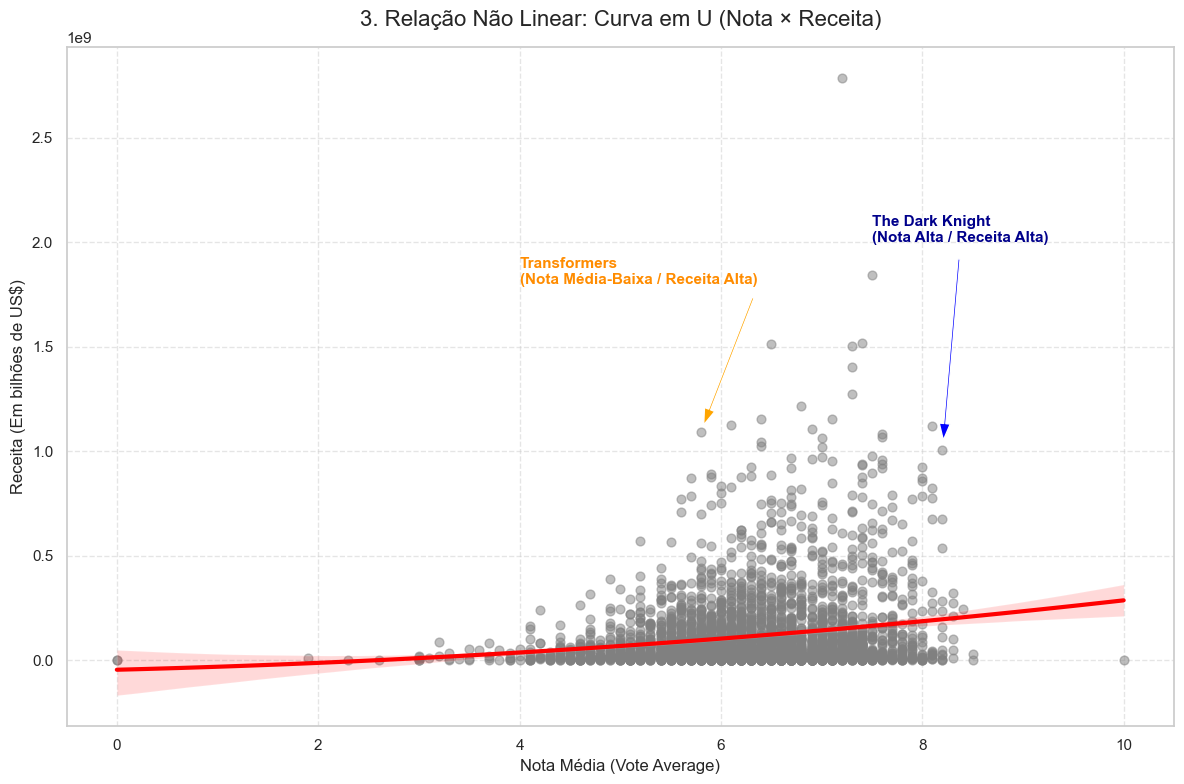

In [27]:
plt.figure(figsize=(12, 8)) # Tamanho ainda maior para o gráfico de dispersão

# Usamos order=2 para forçar o Seaborn a desenhar uma curva polinomial, não uma reta
sns.regplot(data=df, x='vote_average', y='revenue', 
            scatter_kws={'alpha':0.5, 'color':'gray', 's': 40}, # Aumentei o tamanho dos pontos (s=40)
            line_kws={'color':'red', 'linewidth':3}, 
            order=2)

plt.title('3. Relação Não Linear: Curva em U (Nota × Receita)', fontsize=16, pad=15)
plt.xlabel('Nota Média (Vote Average)', fontsize=12)
plt.ylabel('Receita (Em bilhões de US$)', fontsize=12)

# Adicionando anotações de exemplos: The Dark Knight vs Transformers 4
dark_knight = df[df['title'] == 'The Dark Knight'].iloc[0]
transf = df[df['title'] == 'Transformers: Age of Extinction'].iloc[0]

plt.annotate('The Dark Knight\n(Nota Alta / Receita Alta)', 
             xy=(dark_knight['vote_average'], dark_knight['revenue']), 
             xytext=(7.5, 2.0e9),
             arrowprops=dict(facecolor='blue', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, weight='bold', color='darkblue')

plt.annotate('Transformers\n(Nota Média-Baixa / Receita Alta)', 
             xy=(transf['vote_average'], transf['revenue']), 
             xytext=(4.0, 1.8e9),
             arrowprops=dict(facecolor='orange', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, weight='bold', color='darkorange')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análise Extra: Estilo de filmes

,Quantidade,Percentual (%)
genres,,
Drama,2297,18.89
Comedy,1722,14.16
Thriller,1274,10.48
Action,1154,9.49
Romance,894,7.35
Adventure,790,6.50
Crime,696,5.72
Science Fiction,535,4.40
Horror,519,4.27


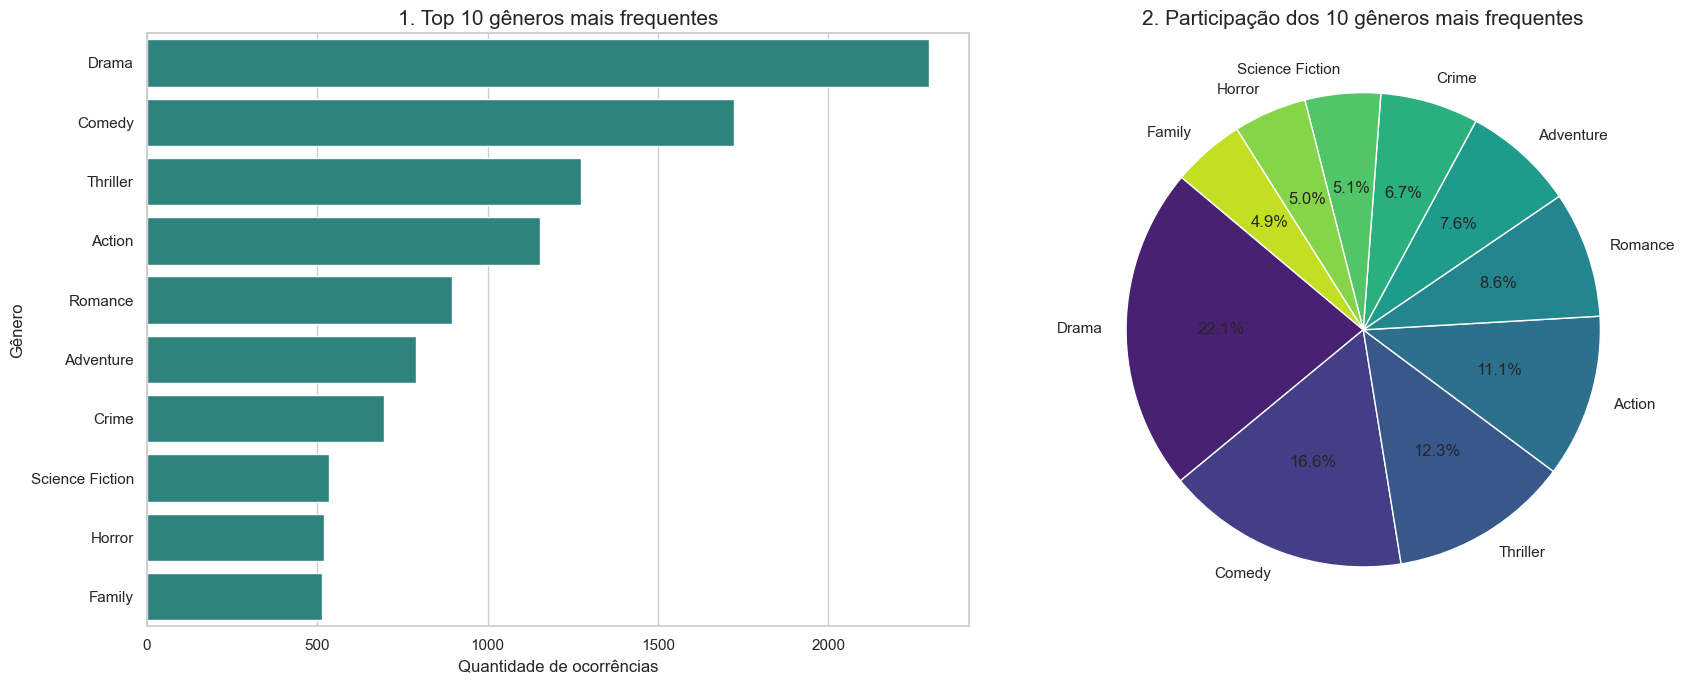

In [30]:
import ast

def extrair_generos(valor):
    if pd.isna(valor) or valor in ['', '[]']:
        return []

    if isinstance(valor, str):
        try:
            valor = ast.literal_eval(valor)
        except (ValueError, SyntaxError):
            return []

    if not isinstance(valor, list):
        return []

    generos = []
    for item in valor:
        if isinstance(item, dict) and 'name' in item:
            generos.append(item['name'])
        elif isinstance(item, str):
            generos.append(item)
    return generos

generos_df = df['genres'].apply(extrair_generos).explode().dropna()
contagem_generos = generos_df.value_counts()
total_generos = contagem_generos.sum()

resumo_generos = pd.DataFrame({
    'Quantidade': contagem_generos,
    'Percentual (%)': (contagem_generos / total_generos * 100).round(2)
})

display(resumo_generos)

top_generos = contagem_generos.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=top_generos.values, y=top_generos.index, ax=axes[0], color=sns.color_palette('viridis', 5)[2])
axes[0].set_title('1. Top 10 gêneros mais frequentes', fontsize=15)
axes[0].set_xlabel('Quantidade de ocorrências')
axes[0].set_ylabel('Gênero')

cores = sns.color_palette('viridis', len(top_generos))
axes[1].pie(top_generos.values, labels=top_generos.index, autopct='%1.1f%%', startangle=140, colors=cores)
axes[1].set_title('2. Participação dos 10 gêneros mais frequentes', fontsize=15)

plt.tight_layout()
plt.show()

Genero x Receita

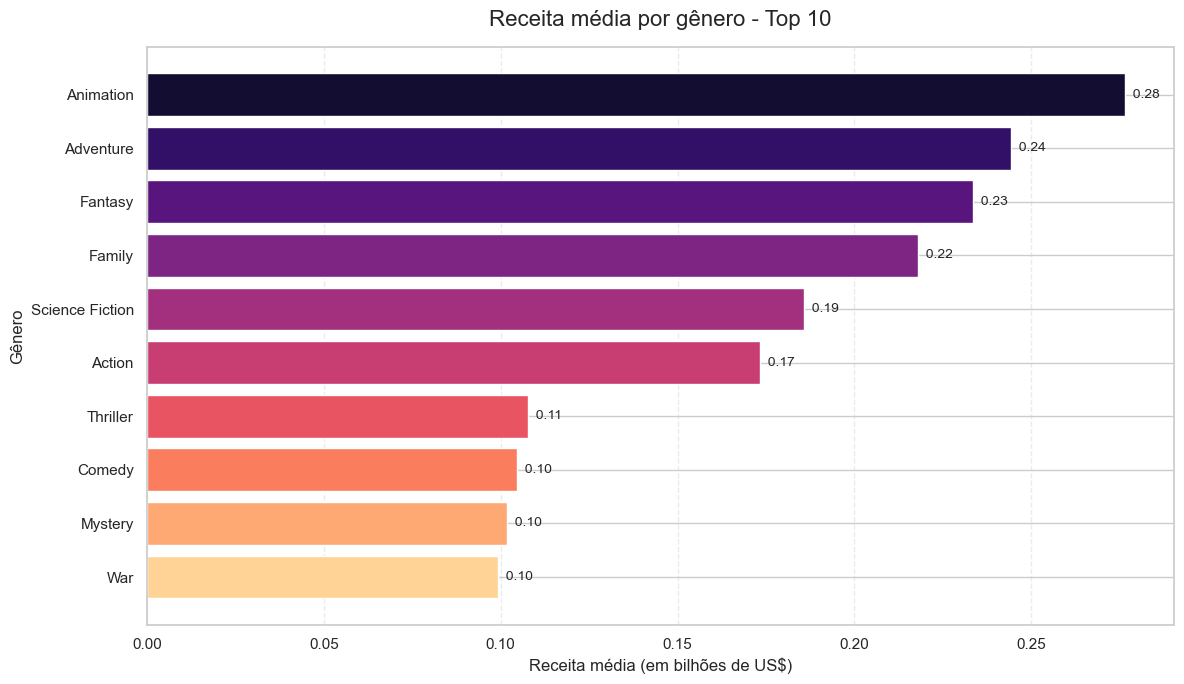

In [32]:
import ast

def extrair_generos(valor):
    if pd.isna(valor) or valor in ['', '[]']:
        return []

    if isinstance(valor, str):
        try:
            valor = ast.literal_eval(valor)
        except (ValueError, SyntaxError):
            return []

    if not isinstance(valor, list):
        return []

    generos = []
    for item in valor:
        if isinstance(item, dict) and 'name' in item:
            generos.append(item['name'])
        elif isinstance(item, str):
            generos.append(item)
    return generos

df_generos = df[['genres', 'revenue']].copy()
df_generos['genres'] = df_generos['genres'].apply(extrair_generos)
df_generos = df_generos.explode('genres').dropna(subset=['genres', 'revenue'])
df_generos = df_generos[df_generos['revenue'] > 0]

receita_media_generos = df_generos.groupby('genres')['revenue'].mean().sort_values(ascending=False)
top_receita_generos = receita_media_generos.head(10)

plt.figure(figsize=(12, 7))
valores = top_receita_generos.values / 1e9
cores = sns.color_palette('magma', len(top_receita_generos))
plt.barh(top_receita_generos.index, valores, color=cores)
plt.gca().invert_yaxis()
plt.title('Receita média por gênero - Top 10', fontsize=16, pad=15)
plt.xlabel('Receita média (em bilhões de US$)')
plt.ylabel('Gênero')

for i, valor in enumerate(valores):
    plt.text(valor, i, f'  {valor:.2f}', va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Receita total por genero:

O gênero com maior receita total é Adventure, com aproximadamente US$ 164.84 bilhões.


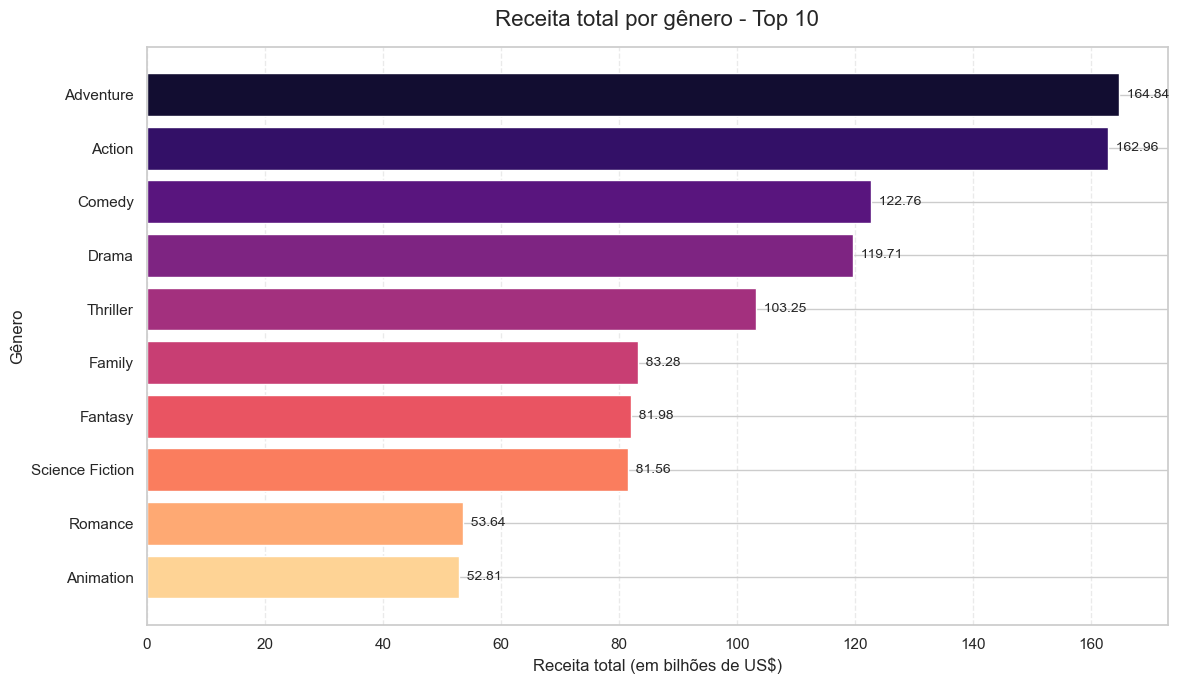

In [33]:
import ast

def extrair_generos(valor):
    if pd.isna(valor) or valor in ['', '[]']:
        return []

    if isinstance(valor, str):
        try:
            valor = ast.literal_eval(valor)
        except (ValueError, SyntaxError):
            return []

    if not isinstance(valor, list):
        return []

    generos = []
    for item in valor:
        if isinstance(item, dict) and 'name' in item:
            generos.append(item['name'])
        elif isinstance(item, str):
            generos.append(item)
    return generos

df_generos_receita = df[['genres', 'revenue']].copy()
df_generos_receita['genres'] = df_generos_receita['genres'].apply(extrair_generos)
df_generos_receita = df_generos_receita.explode('genres').dropna(subset=['genres', 'revenue'])
df_generos_receita = df_generos_receita[df_generos_receita['revenue'] > 0]

receita_total_por_genero = df_generos_receita.groupby('genres')['revenue'].sum().sort_values(ascending=False)
top_receita_total = receita_total_por_genero.head(10)
genero_mais_receita = receita_total_por_genero.idxmax()
valor_mais_receita = receita_total_por_genero.max() / 1e9

print(f'O gênero com maior receita total é {genero_mais_receita}, com aproximadamente US$ {valor_mais_receita:.2f} bilhões.')

plt.figure(figsize=(12, 7))
valores = top_receita_total.values / 1e9
cores = sns.color_palette('magma', len(top_receita_total))
plt.barh(top_receita_total.index, valores, color=cores)
plt.gca().invert_yaxis()
plt.title('Receita total por gênero - Top 10', fontsize=16, pad=15)
plt.xlabel('Receita total (em bilhões de US$)')
plt.ylabel('Gênero')

for i, valor in enumerate(valores):
    plt.text(valor, i, f'  {valor:.2f}', va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Conclusões:
- Drama é o genero mais comum, mas não é o mais lucrativo
- Filmes de aventura geraram muito, mas isso é fruto dos grandes blockbusters (como vingadores)
- Animação tem a melhor média, mas nao tem uma boa renda total, já que é um estilo com poucas produções.
- Filmes de drama não tem uma boa média de receita, e isso se deve aos pequenos filmes que não estouram e acabam puxando a média para baixo. 